In [23]:
### env: chip_seq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interpn
import pickle, lzma
import pyranges as pr
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from scipy.optimize import curve_fit

color_map = {'tmC': '#3B1B4B', 'mC': '#db4d47', 'hmC': '#458B58'}

In [24]:
def density_scatter(x, y, ax=None, sort=True, legend = False,bins=20, vline=True, hline=True, s=1, diag=False, cmap='viridis', **kwargs):
    """
    Scatter plot colored by 2D histogram density, with optional lines and color legend.
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Compute 2D histogram
    data, x_e, y_e = np.histogram2d(x, y, bins=bins, density=True)

    # Interpolate density values
    z = interpn(
        (0.5 * (x_e[1:] + x_e[:-1]), 0.5 * (y_e[1:] + y_e[:-1])),
        data,
        np.vstack([x, y]).T,
        method="splinef2d",
        bounds_error=False
    )
    z[np.isnan(z)] = 0.0  # Replace NaNs

    # Sort points by density
    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    # Plot
    sc = ax.scatter(x, y, c=z, s=s, cmap=cmap, **kwargs)

    # Add reference lines
    if vline:
        ax.axvline(0, color='gray', lw=1, linestyle='--')
    if hline:
        ax.axhline(0, color='gray', lw=1, linestyle='--')
    if diag:
        ax.axline((0, 0), slope=1, color='red', linestyle='--')

    # Add colorbar
    if legend == True:
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label('Density')

    return ax

In [3]:
period_palette={'Infancy': '#F7C98A',
'Early_Childhood': '#F4A154',
'Late_Childhood': '#EF7A3B',
'Adolescence': '#D2614D',
'Early_Adulthood': '#9D4255',
'Adulthood': '#9D4255',
'Late_Adulthood': '#774147'}

In [4]:
chip_meta = pd.read_csv('./data/chip_meta.csv',sep = ',')
chip_meta['age'] = round(chip_meta['age'],3)
chip_meta['id'] = chip_meta['id'].astype(str)
chip_meta_unique = chip_meta[['id', 'age','sex']].drop_duplicates().sort_values('age')
chip_meta_unique['id'] = chip_meta_unique['id'].astype('str')

In [ ]:
geneRef = pd.read_csv('./data/geneID2name.bed',sep='\t',names = ['chr','start','end','geneID','Gene','strand','biotype'])
geneRef.set_index(['geneID','Gene'],inplace = True)
geneRef = geneRef.loc[~ geneRef['chr'].isin(['chrY'])]
geneRef = geneRef[geneRef['chr'].str.match(r'chr\d+$')]  # keep only numbered chromosomes
geneRef['chr'] = geneRef['chr'].str.extract(r'chr(\d+)').astype(int)
geneRef['length'] = (geneRef['end'] - geneRef['start'])
geneRef['TSS'] = geneRef.apply(lambda row: row['start'] if row['strand'] == '+' else row['end'], axis=1)

In [6]:
def exponential(x, a, b, c):
    return a * np.exp(-1 / b * x) + c

## Load H3K27Ac Signal at Peaks

In [5]:
with open('./data/H3K27Ac_RPKM.pkl', 'rb') as f:
    df_TMM = pickle.load(f)

## Heatmap

/home/AD/hex002/miniconda3/envs/chip_seq/lib/python3.11/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)
/tmp/ipykernel_1811624/3633413903.py:67: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()
/home/AD/hex002/miniconda3/envs/chip_seq/lib/python3.11/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)
/tmp/ipykernel_1811624/3633413903.py:67: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


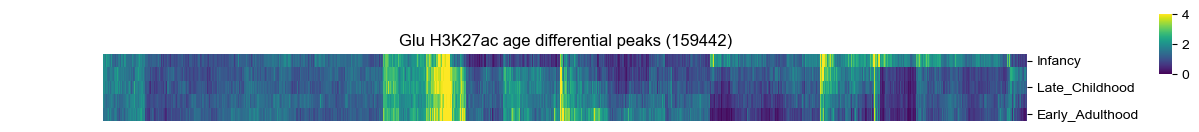

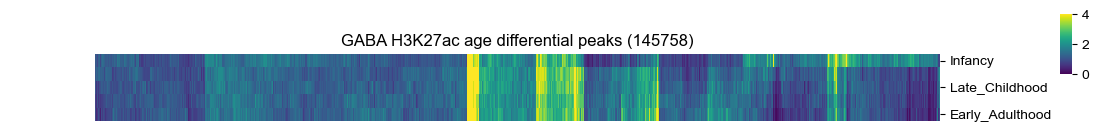

In [40]:
for celltype in ['Glu','GABA']:
    all_peaks = pd.read_csv(f'./data/{celltype}_Ac_peaks_annotated_EDGER.csv.gz', sep = '\t')
    all_peaks['Chromosome'] = all_peaks['Chromosome'].astype('str')
    all_peaks.set_index(['Chromosome','Start','End'],inplace = True)

    cluster_df = df_TMM[f'{celltype}_{celltype}'].loc[all_peaks.index, (slice(None), slice(None))]

    cluster_df = cluster_df.groupby(level=1, axis=1).mean()
    cluster_df = cluster_df[["Infancy", "Early_Childhood", "Late_Childhood", "Adolescence", "Early_Adulthood"]]

    # Add 'trend' labels
    cluster_df['trend'] = all_peaks['trend']

    # Perform clustering within each trend group and concatenate results
    ordered_dfs = []
    row_colors = []

    palette = sns.color_palette('tab10', len(cluster_df['trend'].unique()))
    trend_color_mapping = {trend: palette[i] for i, trend in enumerate(sorted(cluster_df['trend'].unique()))}

    # for trend_group in sorted(cluster_df['trend'].unique()):
    for trend_group in [ 'Non-differential', 'Fast Open','Gradual Open', 'Gradual Close', 'Fast Close','Transient']:
        sub_df = cluster_df[cluster_df['trend'] == trend_group].drop(columns='trend')

        # Perform clustering within each trend group
        cg = sns.clustermap(
            sub_df,
            method='ward',
            col_cluster=False,
            row_cluster=True,
            cmap='viridis',
            linewidths=0,
            figsize=(8, 6),
            cbar_pos=None,
            dendrogram_ratio=0.1,
            rasterized=True
        )
        plt.close()  # Close the intermediate plots
        
        ordered_sub_df = sub_df.iloc[cg.dendrogram_row.reordered_ind]
        ordered_dfs.append(ordered_sub_df)
        row_colors.extend([trend_color_mapping[trend_group]] * len(ordered_sub_df))

    # Concatenate clustered DataFrames
    concatenated_df = pd.concat(ordered_dfs)

    # Plot the final concatenated heatmap
    g = sns.clustermap(
        concatenated_df.T,
        row_cluster=False,
        col_cluster=False,
        cmap='viridis',
                    linewidths=0,
                    vmin = 0, vmax = 4,
                    figsize=(12* (cluster_df.shape[0]/145758), 1.2),  # Adjust the figure size
                    dendrogram_ratio=(0.001, 0.2),  # Reduce the dendrogram's size to make it effectively invisible
                    cbar_pos=(1, 0.5, 0.01, 0.5),rasterized=True)  # Place the color bar on the right side

    # Turn off the row labels and ticks
    g.ax_heatmap.set_xticklabels([])
    g.ax_heatmap.tick_params(bottom=False, left=False)  
    g.ax_heatmap.set_xlabel('')

    # Make the dendrogram for rows invisible
    g.ax_col_dendrogram.set_visible(False)
    g.ax_heatmap.set_title(f'{celltype} H3K27ac age differential peaks ({cluster_df.shape[0]})')
    plt.tight_layout()
    
    # plt.savefig(f"Peak_ChIP_Counts/differential_results_TMM_EDGER_results/{celltype}_{assay}_diff_heatmap.pdf", format="pdf", dpi=300, bbox_inches='tight')
    

## Load Methylation at Peaks

In [26]:
with lzma.open('./data/Methylation_H3K27ac_Peaks.pkl', 'rb') as f:
    binc_celltype_peaks = pickle.load(f)

/tmp/ipykernel_1811624/3268810009.py:25: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  binc_average = binc.sort_index().mean(axis=1, level=[1,2,3,4])


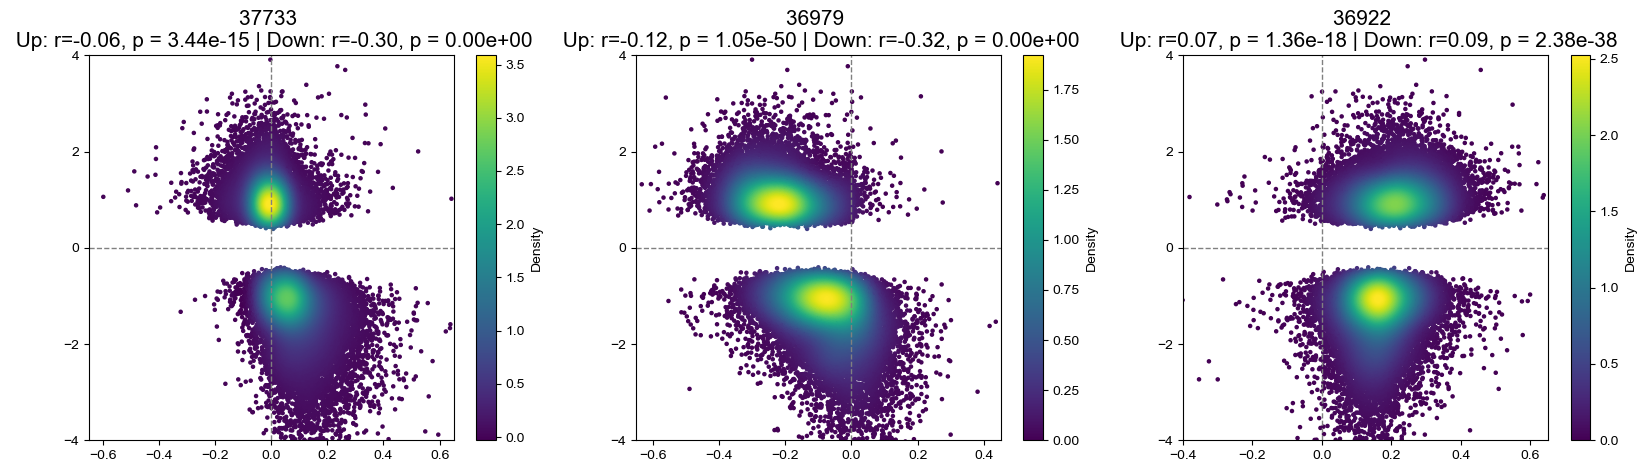

/tmp/ipykernel_1811624/3268810009.py:25: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  binc_average = binc.sort_index().mean(axis=1, level=[1,2,3,4])


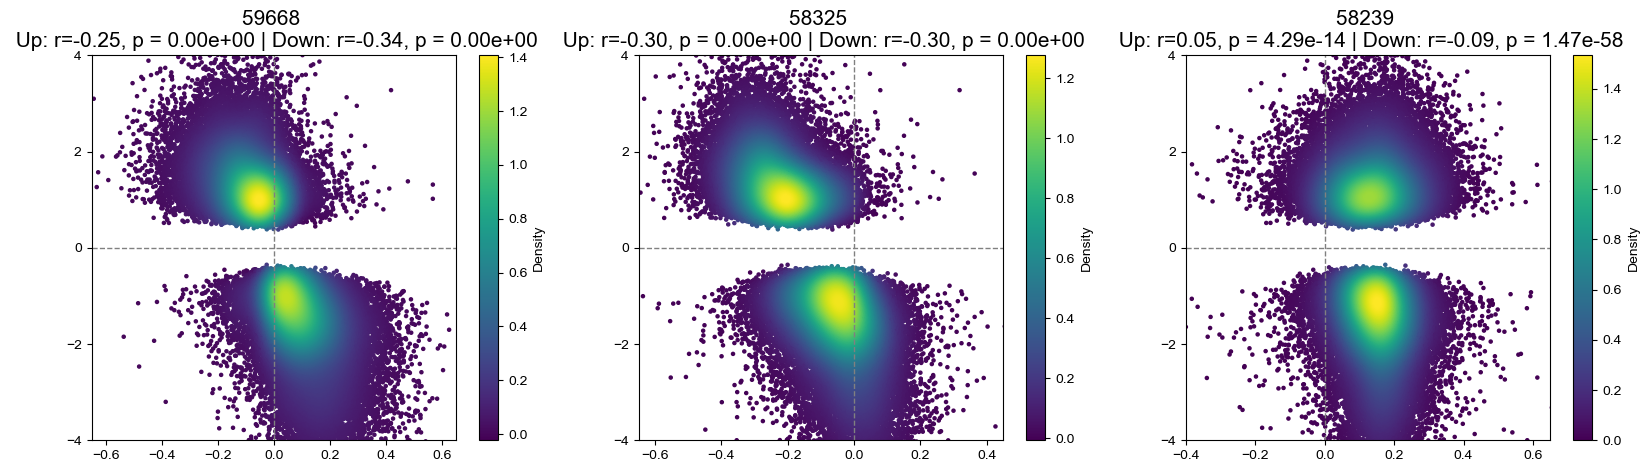

In [62]:
assay = 'Ac'

for cell in ['GABA','Glu']:    

    differential_peaks = pd.read_csv(f'./data/{cell}_{assay}_differential_results_EDGER.csv.gz')

    differential_peaks.rename(columns={
    'CHR': 'Chromosome',
    'START': 'Start',
    'END': 'End',
    'logFC': 'Fold',
    'AgeGroup1':'Group1',
    'AgeGroup2':'Group2'
    }, inplace=True)

    all_peaks = pd.read_csv(f'./data/{cell}_{assay}_peaks_annotated_EDGER.csv.gz', sep = '\t')
    all_peaks['Chromosome'] = all_peaks['Chromosome'].astype('str')
    all_peaks.set_index(['Chromosome','Start','End'],inplace = True)
    all_peaks = all_peaks[(all_peaks['TSS'] == 'Enhancers') ]
    all_peaks = all_peaks[(all_peaks['trend'] != 'Transient')  & (all_peaks['trend'] != 'Non-differential') ]

    binc = binc_celltype_peaks[cell]

    binc_average = binc.sort_index().mean(axis=1, level=[1,2,3,4])    

    binc_average = binc_average.loc[binc_average.index.isin(all_peaks.index)]
    binc_average_hmC = binc_average.loc[:,(slice(None),cell,'BS',slice(None))] - binc_average.loc[:,(slice(None),cell,'OXBS',slice(None))].values
    binc_average_hmC[binc_average_hmC < 0] = 0
    binc_average_hmC.columns = binc_average_hmC.columns.set_levels(['hmc'], level='mctype')
    binc_average_BS = binc_average.loc[:,(slice(None),cell,'BS','CG')]
    binc_average_OXBS = binc_average.loc[:,(slice(None),cell,'OXBS','CG')]
    dataframes = [binc_average_BS, binc_average_OXBS, binc_average_hmC]
    x_scales = [(-0.65,0.65),(-0.65,0.45),(-0.4,0.65)]

    g1, g2 = 'Infancy', 'Adulthood'
    fig, axes = plt.subplots(nrows=1, ncols=3 ,figsize=(20, 5))  
    titles = ['TmCG', 'mCG', 'hmCG']

    for ax, df, title,xscale in zip(axes, dataframes, titles,x_scales):
        df = df.copy()
        
        
        df['Difference'] = df[g2] - df[g1]
        # df['Difference'] = np.log2(df[g2] / df[g1])
        df = df[['Difference']] 
        df['Difference'] = df['Difference'].replace([np.inf, -np.inf], np.nan)
        df.columns = ['Difference']
        
        
        chip_fold = differential_peaks[
            (differential_peaks['Group1'] == g1) &
            (differential_peaks['Group2'] == 'Early_Adulthood') 
        ].copy()

        # Set index and retain only 'Fold' column
        chip_fold.set_index(['Chromosome', 'Start', 'End'], inplace=True)
        chip_fold = chip_fold[['Fold']]
        chip_fold['Fold'] = - chip_fold['Fold'] 

        # Merge with df on index
        df = df.merge(chip_fold, left_index=True, right_index=True)
        df = df.dropna()
        df = df.join(all_peaks[['trend']])
        # Generate density scatter plot
        
        df_up   = df[df['Fold'] > 0]
        df_down = df[df['Fold'] < 0]

        txt = []

        if len(df_up) > 10:
            r_up, p_up = pearsonr(df_up['Difference'], df_up['Fold'])
            txt.append(f"Up: r={r_up:.2f}, p = {p_up:.2e}")

        if len(df_down) > 10:
            r_dn, p_dn = pearsonr(df_down['Difference'], df_down['Fold'])
            txt.append(f"Down: r={r_dn:.2f}, p = {p_dn:.2e}")

        correlation_text = " | ".join(txt)
        pos_median = df[df['Fold'] > 0]['Difference'].mean()
        neg_median = df[df['Fold'] < 0]['Difference'].mean()
        density_scatter(x=df['Difference'], y=df['Fold'], ax=ax,legend =True, rasterized=True,s = 5)

        ax.set_title(f'{df.shape[0]} \n {correlation_text}', size=15)
        ax.set_ylabel('', size=13)
        ax.set_xlabel(f'', size=13)
        ax.set_xlim(xscale)
        
        ax.set_yticks([-4,-2,0,2,4])
        ax.set_ylim([-4,4])
    
    # plt.savefig(savepath, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
        

## Comparing H3K27ac and Methlyation Dynamics through normalized PCA 

In [18]:
trend_name = {0:'Fast Open',
            1:'Gradual Open',
            2:'Fast Close',
            3:'Gradual Close',
            4:'Transient'}

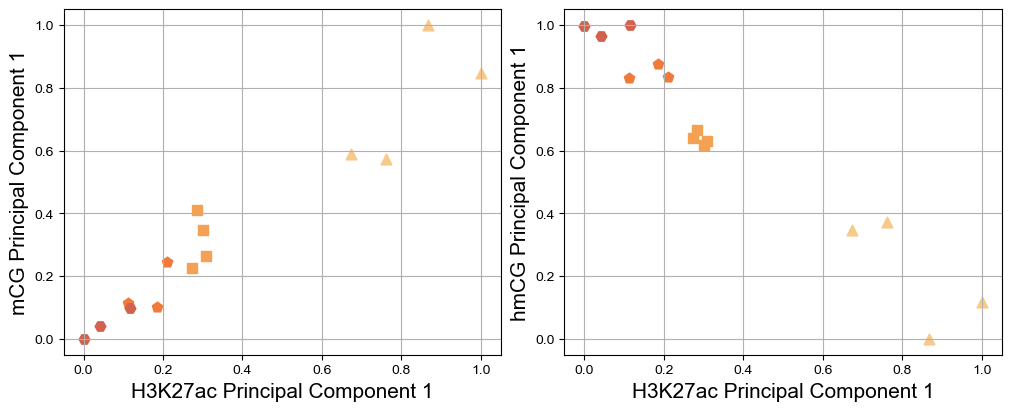

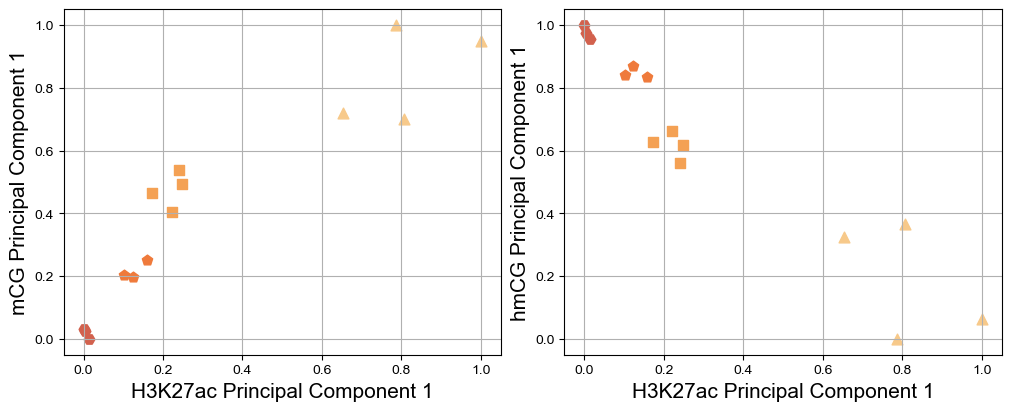

In [44]:
pt_size = 14
for celltype in ['Glu','GABA']:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    axes = axes.flatten()


    all_peaks = pd.read_csv(f'./data/{celltype}_{assay}_peaks_annotated_EDGER.csv.gz', sep = '\t')
    all_peaks['Chromosome'] = all_peaks['Chromosome'].astype('str')
    all_peaks.set_index(['Chromosome','Start','End'],inplace = True)
    all_peaks = all_peaks[all_peaks['TSS'] == 'Enhancers']
    cluster_df = df_TMM[f'{celltype}_{celltype}'].loc[all_peaks[all_peaks['trend'] != 'Non-differential'].index, (slice(None), slice(None))]
    age_tmm = [ 
            chip_meta_unique[chip_meta_unique['id'] == i]['age'].iloc[0]
            for i in cluster_df.columns.get_level_values(0)
        ]

    chip = cluster_df

    mask = binc_celltype_peaks[celltype].index.isin(chip.index)
    binc_masked = binc_celltype_peaks[celltype][mask]
    binc_plot_BS =  binc_masked.loc[:, (slice(None),slice(None), celltype, 'BS', 'CG')]
    binc_plot_hmc = (
        binc_masked.loc[:, (slice(None),slice(None), celltype, 'BS', 'CG')] - 
        binc_masked.loc[:, (slice(None),slice(None),celltype, 'OXBS', 'CG')].values
    )
    binc_plot_oxbs =  binc_masked.loc[:, (slice(None),slice(None),celltype, 'OXBS', 'CG')]

    age_binc = [qcfile[qcfile['donor'] == i]['age'].iloc[0] for i in binc_plot_hmc.columns.get_level_values(0)]

    period_binc = [qcfile[qcfile['donor'] == i]['period'].iloc[0] for i in binc_plot_hmc.columns.get_level_values(0)]

    chip = chip.T        
    pca = PCA(n_components=2)  
    principal_components = pca.fit_transform(chip)
    principal_chip = pd.DataFrame(data = principal_components, columns = ['PC1_chip', 'PC2_chip'])
    principal_chip.index = age_tmm
    
    for idx,binc_PCA in enumerate([binc_plot_oxbs,binc_plot_hmc]):
        ax = axes[idx]
        binc_PCA = binc_PCA.dropna()
        binc_PCA.columns = binc_PCA.columns.get_level_values(0)
        binc_PCA = binc_PCA.T                
        pca = PCA(n_components=2) 
        principal_components = pca.fit_transform(binc_PCA)
        principal_mc = pd.DataFrame(data = principal_components, columns = ['PC1_mc', 'PC2_mc'])
        principal_mc.index = age_binc        
        principal_mc['period'] = period_binc
        principal_chip_mc = principal_chip.merge(principal_mc,left_index=True, right_index=True)
        min_max_scaler = MinMaxScaler()
        scaled_columns = pd.DataFrame(
            min_max_scaler.fit_transform(principal_chip_mc.iloc[:, :4]),
            columns=principal_chip_mc.columns[:4],
            index=principal_chip_mc.index
        )

        # Combine the scaled columns with the remaining columns
        principal_chip_mc = pd.concat([scaled_columns, principal_chip_mc.iloc[:, 4:]], axis=1)

        unique_labels = set()
        texts = []
        markers = {"Infancy": '^', "Early_Childhood": 's', "Late_Childhood": 'p', "Adolescence":'H'}
        sex_color = {'Female':'red','Male':'b'}
        for i, point in principal_chip_mc.iterrows():
            # Determine color based on sex
            color = period_palette[point['period']]
            # color = sex_color[point['sex']]
            marker = markers[point['period']]
            if point['period'] not in unique_labels:
                ax.scatter(point['PC1_chip'], point['PC1_mc'], label=point['period'], marker=marker,s = 60,color = color)
                # unique_labels.add(point['period'])
            else:
                ax.scatter(point['PC1_chip'], point['PC1_mc'],  marker=marker,s = 60,color = color)
            
        ax.set_xlabel('H3K27ac Principal Component 1',size = 15)
        if idx == 0:
            ax.set_ylabel('mCG Principal Component 1',size = 15)
        else:
            ax.set_ylabel('hmCG Principal Component 1',size = 15)
        # ax.set_title(f'{celltype} {trend_name[trend]}')
        ax.grid(True)
    # plt.savefig(f"Peak_ChIP_Counts/differential_results_TMM_EDGER_results/{celltype}_methylation_PC.pdf", format="pdf", dpi=300, bbox_inches='tight')        
    plt.show()

## Examining H3K27ac and Methylation Dynamics at Individual Peaks by Fitting Exponential Curve

In [47]:
def exponential(x, a, b, c):
    return a * np.exp(-1 / b * x) + c

def fit_exponential(data, ages, bounds):
    data = np.array(data)
    ages = np.array(ages)

    # Remove NaNs from both arrays
    valid = ~np.isnan(data)
    data_clean = data[valid]
    ages_clean = ages[valid]

    # Not enough points to fit
    if len(data_clean) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    try:
        # Fit the curve
        popt, pcov = curve_fit(exponential, ages_clean, data_clean, maxfev=1000, bounds=bounds)
        perr = np.sqrt(np.diag(pcov))
        predicted = exponential(ages_clean, *popt)
        residuals = data_clean - predicted
        ss_total = np.sum((data_clean - np.mean(data_clean))**2)
        ss_res = np.sum(residuals**2)
        r_squared = 1 - (ss_res / ss_total)
        return popt[1], popt[0], perr[0], perr[1], r_squared
    except Exception:
        return np.nan, np.nan, np.nan, np.nan, np.nan

In [46]:
# bounds = ([-np.inf, 1e-05, -np.inf], [np.inf, 20, np.inf])
# tau_ac_parallel, a_ac_parallel,tau_ac_se_parallel,a_ac_se_parallel,r2_ac_parallel = zip(*Parallel(n_jobs=-1)(delayed(fit_exponential)(row.values, cluster_df_age, bounds) for _, row in cluster_df.iterrows()))
# tau_mc_parallel, a_mc_parallel,tau_mc_se_parallel,a_mc_se_parallel,r2_mc_parallel = zip(*Parallel(n_jobs=-1)(delayed(fit_exponential)(row.values, age_binc, bounds) for _, row in binc_plot_oxbs.iterrows()))
# tau_hmc_parallel, a_hmc_parallel,tau_hmc_se_parallel,a_hmc_se_parallel,r2_hmc_parallel = zip(*Parallel(n_jobs=-1)(delayed(fit_exponential)(row.values, age_binc, bounds) for _, row in binc_plot_hmc.iterrows()))
# fit_chip = pd.DataFrame({
#         'a_ac': a_ac_parallel,
#         'tau_ac': tau_ac_parallel,
#         'a_se_ac': a_ac_se_parallel,
#         'tau_se_ac': tau_ac_se_parallel,
#         'r2_ac': r2_ac_parallel,
#     },index = cluster_df.index)
# fit_hmc = pd.DataFrame({
#         'a_hmc': a_hmc_parallel,
#         'tau_hmc': tau_hmc_parallel,
#         'a_se_hmc': a_hmc_se_parallel,
#         'tau_se_hmc': tau_hmc_se_parallel,
#         'r2_hmc': r2_hmc_parallel,
#     },index = binc_plot_hmc.index)

# fit_mc = pd.DataFrame({
#         'a_mc': a_mc_parallel,
#         'tau_mc': tau_mc_parallel,
#         'a_se_mc': a_mc_se_parallel,
#         'tau_se_mc': tau_mc_se_parallel,
#         'r2_mc': r2_mc_parallel,
#     },index = binc_plot_oxbs.index)
# fit_df = pd.merge(fit_chip, fit_hmc, left_index=True, right_index=True, how='outer')
# fit_df = pd.merge(fit_df, fit_mc, left_index=True, right_index=True, how='outer')
# fit_df.to_csv(f'{cell}_{cell}_dyn_fit.csv.gz')

(83072, 15)
(4667, 15)
(51870, 15)
(8842, 15)


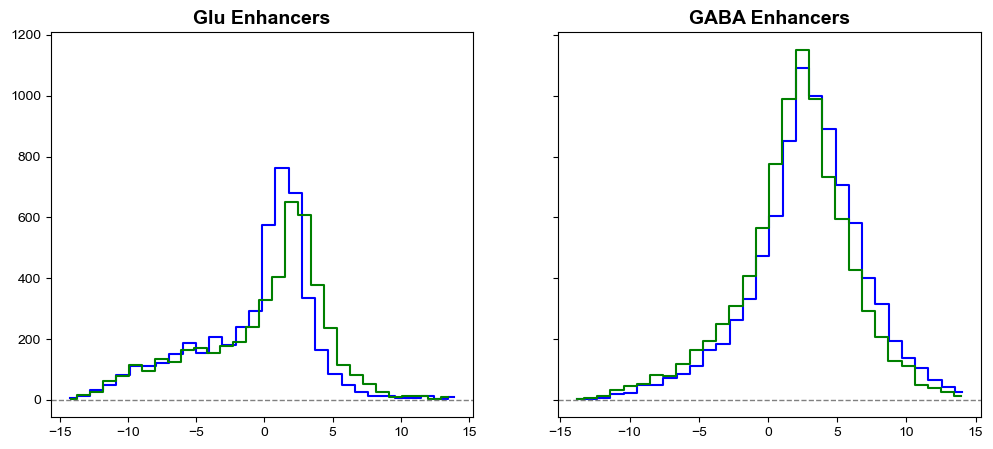

In [ ]:
celltypes = ['Glu', 'GABA']
# Set up figure with shared y-axis
fig, axes = plt.subplots(1, len(celltypes), figsize=(12, 5), sharey=True, dpi=100)

# Define color palettes
line_colors = {"tau_mc_diff": "blue", "tau_hmc_diff": "green"}

for i, celltype in enumerate(celltypes):
    # Read data
    file_path = f'/cndd/hex002/PsychEncode/ChIP/{celltype}_{celltype}_dyn_fit.csv.gz'
    try:
        fit_df = pd.read_csv(file_path, index_col=[0, 1, 2])
    except FileNotFoundError:
        print(f"File {file_path} not found. Skipping {celltype}.")
        continue

    # Apply filtering based on R^2 values
    print(fit_df.shape)
    fit_df = fit_df[
   (fit_df['tau_ac'] < 15) &  
    (fit_df['tau_mc'] < 15) & 
    (fit_df['tau_hmc'] < 15) &
    (fit_df['r2_ac'] >= 0.4) & 
    (fit_df['r2_mc'] >= 0.4) & 
    (fit_df['r2_hmc'] >= 0.4)]
    fit_df = fit_df.dropna()
    # Compute differences
    print(fit_df.shape)
    fit_df['tau_mc_diff'] = fit_df['tau_mc'] - fit_df['tau_ac']
    fit_df['tau_hmc_diff'] = fit_df['tau_hmc'] - fit_df['tau_ac']    
    for tau_diff in ['tau_mc_diff', 'tau_hmc_diff']:
    # Compute histogram with raw counts
        hist, bins = np.histogram(fit_df[tau_diff], bins=30, density=False)
        
        # Convert histogram to line plot
        axes[i].plot(
            (bins[:-1] + bins[1:]) / 2,
            hist,
            drawstyle='steps-mid',
            label=tau_diff.replace('_diff', '').upper(),
            color=line_colors[tau_diff]
        )
    # Horizontal zero line for reference
    axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=1)

    # Set titles and labels
    axes[i].set_title(f'{celltype} Enhancers', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# plt.savefig(f"Peak_ChIP_Counts/differential_results_TMM_EDGER_results/dynamic_comparison.pdf", format="pdf", dpi=300, bbox_inches='tight')

## Individual Peak Example

Text(0.5, 1.0, "('7', 144524381, 144528243)")

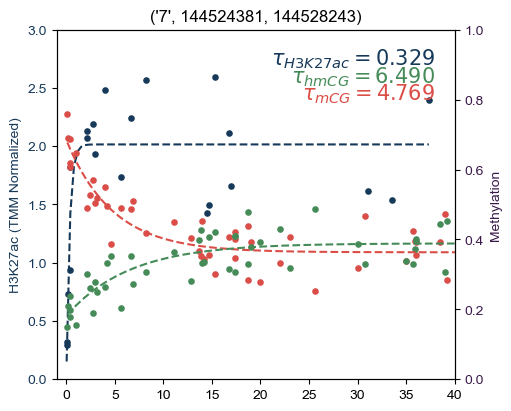

In [61]:
def clean_na(ages,data):
    data = np.array(data)
    ages = np.array(ages)

    # Remove NaNs from both arrays
    valid = ~np.isnan(data)
    data_clean = data[valid]
    ages_clean = ages[valid]
    return ages_clean, data_clean

color_map = {'tmCG': '#3B1B4B', 'mCG': '#db4d47', 'hmCG': '#458B58','H3K27ac': '#173959'}
celltype = 'Glu'
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
# Define peak region
# peak = ('1', 201052903, 201058337)
peak = ('7', 144524381, 144528243)
# Extract TMM-normalized H3K27ac signal
tmm_data = df_TMM[f'{celltype}_{celltype}'].loc[peak, (slice(None), slice(None))]

# Prepare methylation data (hmCG and mCG)
binc_masked = binc_celltype_peaks[celltype]

# Calculate hmCG = BS - OXBS
binc_plot_hmc = (
    binc_masked.loc[peak, (slice(None), slice(None), celltype, 'BS', 'CG')] - 
    binc_masked.loc[peak, (slice(None), slice(None), celltype, 'OXBS', 'CG')].values
)
binc_plot_oxbs = binc_masked.loc[peak, (slice(None), slice(None), celltype, 'OXBS', 'CG')]

# Get age and sex for each donor
age_binc = [qcfile[qcfile['donor'] == i]['age'].iloc[0] for i in binc_plot_hmc.index.get_level_values(0)]

# Fit and plot TMM data (H3K27ac)
popt_tmm, _ = curve_fit(exponential, age_tmm, tmm_data.values, maxfev=10000, bounds=bounds)
x_tmm = np.linspace(np.min(age_tmm), np.max(age_tmm), 100)
y_tmm = exponential(x_tmm, *popt_tmm)

ax.plot(x_tmm, y_tmm, color=color_map['H3K27ac'], linestyle='--', label='TMM Fit')
ax.scatter(age_tmm, tmm_data.values, color=color_map['H3K27ac'], s=pt_size, label='H3K27ac')
ax.text(0.95, 0.95, rf"$\tau_{{H3K27ac}} = {popt_tmm[1]:.3f}$",
        color=color_map['H3K27ac'], fontsize=15, ha='right', va='top', transform=ax.transAxes)

ax.set_ylim(0, 3)
ax.set_ylabel('H3K27ac (TMM Normalized)', color=color_map['H3K27ac'])
ax.tick_params(axis='y', labelcolor=color_map['H3K27ac'])

# Twin y-axis for methylation
ax_right = ax.twinx()

# Fit and plot mCG (OXBS)
age_binc_clean, oxbs = clean_na(age_binc, binc_plot_oxbs.values)
popt_oxbs, _ = curve_fit(exponential, age_binc_clean, oxbs, maxfev=10000, bounds=bounds)
x_oxbs = np.linspace(np.min(age_binc), np.max(age_binc), 1000)
y_oxbs = exponential(x_oxbs, *popt_oxbs)

ax_right.plot(x_oxbs, y_oxbs, color=color_map['mCG'], linestyle='--', label='OXBS Fit')
ax_right.scatter(age_binc, binc_plot_oxbs.values, color=color_map['mCG'], s=pt_size, label='mCG')
ax_right.text(0.95, 0.85, rf"$\tau_{{mCG}} = {popt_oxbs[1]:.3f}$",
              color=color_map['mCG'], fontsize=15, ha='right', va='top', transform=ax_right.transAxes)

# Fit and plot hmCG
age_binc_clean, hmc = clean_na(age_binc, binc_plot_hmc.values)
popt_hmc, _ = curve_fit(exponential, age_binc_clean, hmc, maxfev=10000, bounds=bounds)
x_hmc = np.linspace(np.min(age_binc), np.max(age_binc), 1000)
y_hmc = exponential(x_hmc, *popt_hmc)

ax_right.plot(x_hmc, y_hmc, color=color_map['hmCG'], linestyle='--', label='hmC Fit')
ax_right.scatter(age_binc, binc_plot_hmc.values, color=color_map['hmCG'], s=pt_size, label='hmCG')
ax_right.text(0.95, 0.90, rf"$\tau_{{hmCG}} = {popt_hmc[1]:.3f}$",
              color=color_map['hmCG'], fontsize=15, ha='right', va='top', transform=ax_right.transAxes)

ax_right.set_ylim(0, 1)
ax_right.set_ylabel('Methylation', color=color_map['tmCG'])
ax_right.tick_params(axis='y', labelcolor=color_map['tmCG'])

# Set x-axis and title
ax.set_xlim(-1, 40)
ax.set_title(f'{peak}')
# plt.savefig(f"Peak_ChIP_Counts/differential_results_TMM_EDGER_results/{celltype}_{assay}_methylationl_dynamic_{peak[0]}_{peak[1]}.pdf", format="pdf", dpi=300, bbox_inches='tight')

## Methylation Dynamcis at Flanking Regions of Refined Enhancers

In [21]:
with lzma.open('./data/H3K27ac_flanking_Enhancers.pkl', 'rb') as f:
    df_TMM = pickle.load(f)
with lzma.open('./data/Methylation_flanking_Enhancers.pkl', 'rb') as f:
    binc_celltype_peaks = pickle.load(f)

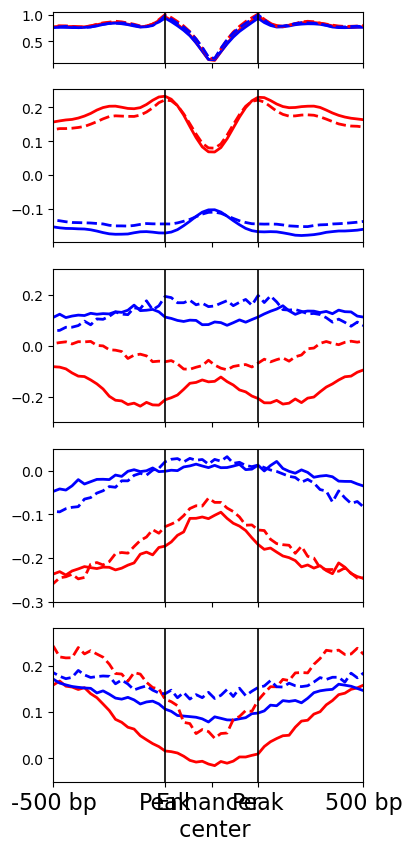

In [ ]:
assay = 'Ac'

celltypes = ['Glu', 'GABA']
cell_ls = {'Glu': '-', 'GABA': '--'}   # dashed for GABA, solid for Glu
regulations = [[0, 1], [2, 3]]
line_colors = ['red', 'blue']          # regulation colors

# ---- Create one shared figure ----
fig, axes = plt.subplots(
    nrows=5, ncols=1,
    figsize=(4, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 3, 3, 3, 3]}
)

for cell in celltypes:
    
    # per-cell objects you already build    

    all_peaks = pd.read_csv(f'./data/{cell}_{assay}_peaks_annotated_EDGER.csv.gz', sep='\t')
    all_peaks['Chromosome'] = all_peaks['Chromosome'].astype('str')
    all_peaks['length'] = all_peaks['End'] - all_peaks['Start']
    all_peaks.set_index(['Chromosome','Start','End'], inplace=True)
    all_peaks = all_peaks[(all_peaks['TSS'] == 'Enhancers')]
    binc = binc_celltype_peaks[cell]

    center_ref = pd.read_csv(
        f'/cndd/hex002/PsychEncode/ChIP/Alex_refined_peaks/{cell}.refined_enhancer_peaks_100bp.all_nucs.version2.bed',
        sep='\t', names=['center_Chromosome','center_Start','center_End','peak_name'], index_col=False
    )
    center_ref[['Chromosome', 'Start', 'End']] = center_ref['peak_name'].str.split('[:\-]', expand=True)
    center_ref['Chromosome'] = center_ref['Chromosome'].str.replace('chr','')
    center_ref['center_Chromosome'] = center_ref['center_Chromosome'].str.replace('chr','')
    center_ref['Start'] = center_ref['Start'].astype('int') - 1
    center_ref['End'] = center_ref['End'].astype('int')
    center_ref.set_index(['Chromosome','Start','End'], inplace=True)

    nucleosome_pos = pd.read_csv(
        f'/cndd/hex002/PsychEncode/ChIP/Alex_refined_peaks/2025_05_13/{cell}_inf_adu_nucleosome_positions.bed',
        sep='\t', header=None,
        names=['Chromosome','Start','End','center','score1','score2']
    )
    nucleosome_pos['Chromosome'] = nucleosome_pos['Chromosome'].str.replace('chr', '', regex=False)

    # ---- Now plot both regulations for this cell onto the same axes ----
    for (regulation, line_color) in zip(regulations, line_colors):

        differential_peaks_subset = all_peaks[all_peaks['trend'].isin([trend_name[regulation[0]], trend_name[regulation[1]]])]
        differential_peaks_subset_index = differential_peaks_subset.index
        differential_peaks_subset_index = differential_peaks_subset_index[differential_peaks_subset_index.isin(center_ref.index)]

        center_ref_sub = center_ref.loc[differential_peaks_subset_index].reset_index()
        center_ref_sub.set_index(['center_Chromosome','center_Start','center_End'], inplace=True)
        center_ref_sub.index.names = ['Chromosome','Start','End']

        differential_peaks_subset_index = center_ref_sub.index[center_ref_sub.index.isin(binc.reset_index(level=3).index)]

        # --- compute nucleosome_density exactly as you already do ---
        center_ref_sub_peak_name = center_ref_sub[['peak_name']].reset_index()
        bin = 20
        num_bins = 50
        all_bins = []
        for idx, row in center_ref_sub_peak_name.iterrows():
            chrom = row['Chromosome']
            center = (row['Start'] + row['End']) // 2
            for i in range(2 * num_bins):
                bin_start = center - bin * num_bins + i * bin
                bin_end = bin_start + bin
                bin_index = i + 1
                all_bins.append([chrom, bin_start, bin_end, idx, bin_index])

        bins_df = pd.DataFrame(all_bins, columns=["Chromosome","Start","End","RowIndex","BinIndex"])
        bins_gr = pr.PyRanges(bins_df)
        nucleosome_gr = pr.PyRanges(nucleosome_pos)

        overlap_df = bins_gr.count_overlaps(nucleosome_gr).df
        region_keys = center_ref_sub_peak_name.loc[overlap_df['RowIndex'], ['Chromosome','Start','End']].reset_index(drop=True)
        overlap_df[['Region_Chrom','Region_Start','Region_End']] = region_keys

        nucleosome_density = overlap_df.pivot_table(
            index=['Region_Chrom','Region_Start','Region_End'],
            columns='BinIndex',
            values='NumberOverlaps',
            fill_value=0
        ).sort_index(axis=1)
        nucleosome_density.index.names = ['Chromosome','Start','End']

        # --- methylation frames (as-is) ---
        binc_average = binc.reset_index(level=3).loc[differential_peaks_subset_index, :].set_index('index')
        binc_average_hmC = binc_average.loc[:, (slice(None),cell,'BS',slice(None))] - binc_average.loc[:, (slice(None),cell,'OXBS',slice(None))].values
        binc_average_hmC[binc_average_hmC < 0] = np.nan
        binc_average_hmC = binc_average_hmC.groupby(level=0).median()
        binc_average_hmC.columns = binc_average_hmC.columns.set_levels(['hmc'], level='mctype')
        binc_average_BS = binc_average.loc[:, (slice(None),cell,'BS','CG')].groupby(level=0).median()
        binc_average_OXBS = binc_average.loc[:, (slice(None),cell,'OXBS','CG')].groupby(level=0).median()

        # ====== PLOTTING (linestyle encodes celltype) ======
        ls = cell_ls[cell]
        label_prefix = f"{cell}"

        # (0) nucleosome
        ax = axes[0]
        ax.plot(
            nucleosome_density.loc[differential_peaks_subset_index].mean(axis=0),
            color=line_color, linestyle=ls, linewidth=2,
            label=f"{label_prefix} | {trend_name[regulation[0]]}/{trend_name[regulation[1]]}"
        )        

        # (1) K27ac
        ax = axes[1]
        TMM_DP = df_TMM[f'Ac_{cell}_{cell}'].loc[differential_peaks_subset_index]
        TMM_DP_tmp = TMM_DP.mean(axis=0)
        ax.plot(
            TMM_DP_tmp['Infancy'].index,
            TMM_DP_tmp['Early_Adulthood'].values - TMM_DP_tmp['Infancy'].values,
            color=line_color, linestyle=ls, linewidth=2
        )

        # (2-4) methylation
        dataframes = [binc_average_BS, binc_average_OXBS, binc_average_hmC]
        y_scales = [(-0.3,0.3), (-0.3,0.05), (-0.05,0.28)]
        for ax, df, y_scale in zip(axes[2:], dataframes, y_scales):
            ax.plot(
                df.index,
                df['Early_Adulthood'] - df['Infancy'],
                color=line_color, linestyle=ls, linewidth=2
            )
            ax.set_ylim(y_scale)
        # ax.set_xlim([25,75])
        # ax.set_xticks([25,50.5,75])
        # ax.set_xticklabels(['-500 bp', 'Enhancer \n center', '500 bp'],size = 16)
nucl_mean = nucleosome_density.loc[differential_peaks_subset_index].mean(axis=0)

# top-2 bins by value (largest 2 y's)
top2 = nucl_mean.nlargest(2)          # Series: index=BinIndex, values=mean density
x_peaks = list(top2.index)            # two x positions (BinIndex)

base_ticks  = [25, 50.5, 75]

# peak ticks (must be numeric and within [25,75])
peak_ticks = sorted([float(x) for x in x_peaks if 25 <= float(x) <= 75])

# combine + keep unique (and ordered)
all_ticks = sorted(set(base_ticks + peak_ticks))

# labels: give labels only for base ticks + peaks (or blank others)
labels = []
for t in all_ticks:
    if np.isclose(t, 25):   labels.append('-500 bp')
    elif np.isclose(t, 50.5): labels.append('Enhancer \n center')
    elif np.isclose(t, 75): labels.append('500 bp')
    elif t in peak_ticks:   labels.append('Peak')
    else:                   labels.append('')

for ax in axes:
    ax.set_xlim([25, 75])
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(labels, size=16)

for axv in (axes[0], axes[1],axes[2],axes[3],axes[4]):
    for j, x_peak in enumerate(x_peaks):
        axv.axvline(
            x=x_peak,
            color='black',
            linestyle="-",
            linewidth=1.2,
            alpha=1,
        )                    
# output_path = f"/cndd/hex002/PsychEncode/ChIP/Alex_refined_peaks/{assay}_median_diff_500bp_combined.pdf"
# plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')            